## Modul 3 : Python untuk Data dan Dataset Terbuka

### Api key

In [15]:
import io
import os
from dotenv import load_dotenv
from google import genai
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from PIL import Image

# 1. Muat API key dari file .env
load_dotenv()

# 2. Inisialisasi client (otomatis mendeteksi GEMINI_API_KEY dari .env)
client = genai.Client()


def penjelasan(fig=None, instruksi_tambahan=""):
    """Mengambil grafik aktif, mengirim ke Gemini, dan menampilkan penjelasan Markdown."""
    if fig is None:
        fig = plt.gcf()

    # Simpan grafik ke RAM
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    # Prompt instruksi
    prompt = f"""
    Jelaskan grafik ini secara sederhana, gunakan bahasa yang mudah dimengerti, 
    hindari istilah teknis yang rumit, dan sertakan contoh atau analogi jika memungkinkan. 
    Gunakan format penjelasan yang menarik dan mudah dibaca.
    {instruksi_tambahan}
    """

    # Model resmi Google GenAI
    daftar_model = ["gemini-3.8-flash", "gemini-3.5-flash", "gemini-3.5-flash-lite"]
    response_text = None

    for model_name in daftar_model:
        try:
            response = client.models.generate_content(
                model=model_name, contents=[img, prompt]
            )
            response_text = response.text
            break
        except Exception as e:
            print(f"Percobaan dengan {model_name} gagal: {e}")
            continue
        
    if response_text:
        display(Markdown(response_text))
    else:
        print("Gagal mendapatkan penjelasan dari AI. Silakan coba lagi.")

### Kegiatan 1 — NumPy: Operasi Vektor

In [21]:
import numpy as np 

uts = np.array([78, 90, 66, 85, 72])
uas = np.array([80, 94, 52, 88, 75])

nilai_akhir = 0.4 * uts + 0.6 * uas
print("Nilai akhir :", nilai_akhir)
print("Rata-Rata   :", nilai_akhir.mean())
print("Tertinggi   :", nilai_akhir.max())

Nilai akhir : [79.2 92.4 57.6 86.8 73.8]
Rata-Rata   : 77.96000000000001
Tertinggi   : 92.4


#### Pengembangan 1

In [22]:
import numpy as np 

uts = np.array([78, 90, 22, 90, 30])
uas = np.array([80, 94, 100, 88, 75])

nilai_akhir = 0.4 * uts + 0.6 * uas
print("Nilai akhir :", nilai_akhir)
print("Rata-Rata   :", round(nilai_akhir.mean(), 2))
print("Tertinggi   :", nilai_akhir.max())

print("Terendah    :", nilai_akhir.min())

lulus = nilai_akhir >= 80
print("Jumlah orang yang lulus", np.sum(lulus), "orang")

Nilai akhir : [79.2 92.4 68.8 88.8 57. ]
Rata-Rata   : 77.24
Tertinggi   : 92.4
Terendah    : 57.0
Jumlah orang yang lulus 2 orang


### Kegiatan 2 — Pandas: Membaca dan Mengolah CSV

In [8]:
import pandas as pd 

url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/nilai_mahasiswa.csv'
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe())

df["nilai_akhir"] = 0.4 * df["uts"] + 0.6 * df["uas"]

pintar = df[df["nilai_akhir"] > 80]
print(pintar[["nama", "kelas", "nilai_akhir"]])

print(df.groupby("kelas")["nilai_akhir"].mean())

        nim          nama  kelas  uts  uas  kehadiran
0  20260001  Budi Pratama  TI-3A   85   77         70
1  20260002  Sari Santoso  TI-3A   92   94         77
2  20260003   Andi Wibowo  TI-3A   59   52         93
3  20260004  Rina Lestari  TI-3A   51   41         88
4  20260005  Joko Saputra  TI-3A   72   59         70
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   nim        40 non-null     int64
 1   nama       40 non-null     str  
 2   kelas      40 non-null     str  
 3   uts        40 non-null     int64
 4   uas        40 non-null     int64
 5   kehadiran  40 non-null     int64
dtypes: int64(4), str(2)
memory usage: 2.0 KB
None
                nim        uts         uas   kehadiran
count  4.000000e+01  40.000000   40.000000   40.000000
mean   2.026002e+07  71.450000   70.300000   84.025000
std    1.169045e+01  14.885805   17.907454    9.135694
min    2.0

### Contoh 2

In [24]:
df["nilai_akhir"] = 0.4 * df["uts"] + 0.6 * df["uas"]
pintar = df[df["nilai_akhir"] > 80]

print(pintar[["nama", "kelas", "nilai_akhir"]])
print(df.groupby("kelas")["nilai_akhir"].mean())

             nama  kelas  nilai_akhir
0    Budi Pratama  TI-3A         80.2
1    Sari Santoso  TI-3A         93.2
12   Fajar Wibowo  TI-3A         96.6
20   Budi Pratama  TI-3B         86.4
24   Joko Saputra  TI-3B         99.2
26   Agus Hidayat  TI-3B         88.2
27     Lina Utami  TI-3B         81.4
28  Rizki Nugroho  TI-3B         82.0
29     Putri Sari  TI-3B         91.0
31  Nanda Santoso  TI-3B         84.4
33  Intan Lestari  TI-3B         89.2
36    Eko Hidayat  TI-3B         84.0
37     Tika Utami  TI-3B         94.4
38  Wawan Nugroho  TI-3B         94.4
kelas
TI-3A    64.49
TI-3B    77.03
Name: nilai_akhir, dtype: float64


_**note: jangan run pengembangan 2 untuk menjalankan Kegiatan 3**_

#### Pengembangan 2

In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/fifa_players.csv"
df = pd.read_csv(url)

# Pemain dengan rating tertinggi (>= 88)
top_players = df[df["overall_rating"] >= 88][
    ["name", "age", "nationality", "overall_rating", "potential", "value_euro"]
].sort_values(by="overall_rating", ascending=False)

print("Pemain Bintang (Overall >= 88)")
print(top_players.head(10).to_string(index=False))

# Pemain muda potensial (usia <= 21, potensi >= 85)
young_gems = df[(df["age"] <= 21) & (df["potential"] >= 85)][
    ["name", "age", "nationality", "overall_rating", "potential"]
].sort_values(by="potential", ascending=False)

print("\n Wonderkids (<= 21 Tahun, Potensi >= 85)")
print(young_gems.head(10).to_string(index=False))

# Rata-rata overall rating berdasarkan kewarganegaraan (negara dengan min. 50 pemain)
top_nations = (
    df.groupby("nationality")
    .filter(lambda x: len(x) >= 50)
    .groupby("nationality")["overall_rating"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

print("\n--- Top 5 Negara dengan Rata-rata Rating Tertinggi ---")
print(top_nations.to_string(index=False))

Pemain Bintang (Overall >= 88)
             name  age nationality  overall_rating  potential  value_euro
         L. Messi   31   Argentina              94         94 110500000.0
Cristiano Ronaldo   34    Portugal              94         94  77000000.0
        Neymar Jr   27      Brazil              92         92 108000000.0
        E. Hazard   28     Belgium              91         91  93000000.0
           De Gea   28       Spain              91         93  72000000.0
        L. Suárez   32     Uruguay              91         91  80000000.0
        L. Modrić   33     Croatia              91         91  67000000.0
     K. De Bruyne   27     Belgium              91         92 102000000.0
     G. Chiellini   34       Italy              90         90  31000000.0
   R. Lewandowski   30      Poland              90         90  77000000.0

 Wonderkids (<= 21 Tahun, Potensi >= 85)
           name  age nationality  overall_rating  potential
      K. Mbappé   20      France              88     

### Kegiatan 3 — Visualisasi dengan Matplotlib

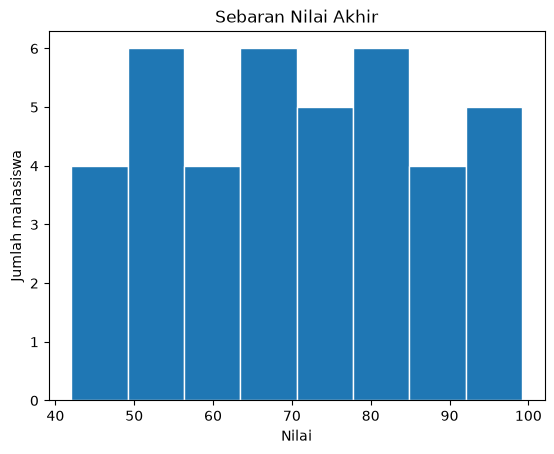

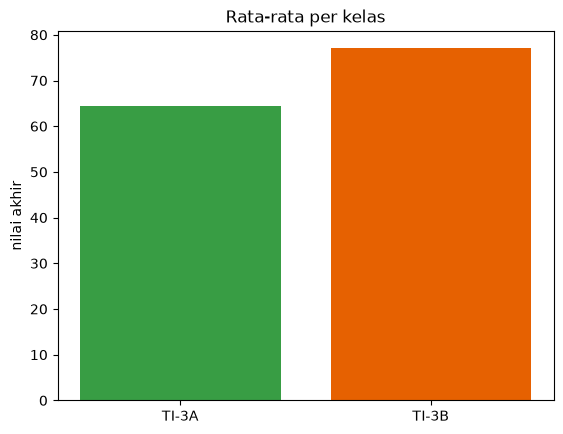

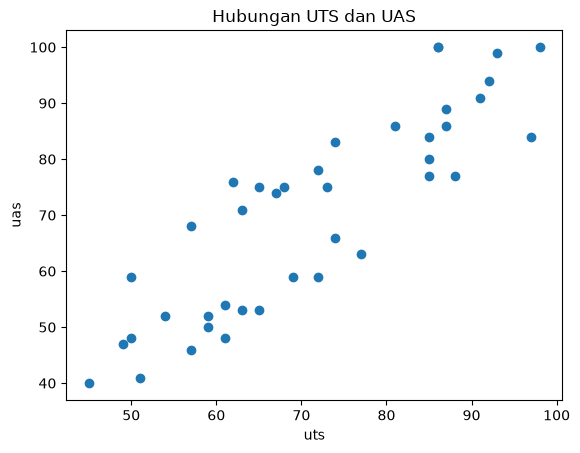

In [16]:
import matplotlib.pyplot as plt

plt.hist(df["nilai_akhir"], bins=8, edgecolor="white")
plt.title("Sebaran Nilai Akhir")
plt.xlabel("Nilai")
plt.ylabel("Jumlah mahasiswa")
plt.show()

# bar chart
rata_kelas = df.groupby("kelas")["nilai_akhir"].mean()

plt.bar(rata_kelas.index, rata_kelas.values, color=["#389d44", "#e66101"])
plt.title("Rata-rata per kelas")
plt.ylabel("nilai akhir")
plt.show()

plt.scatter(df["uts"], df["uas"])
plt.title("Hubungan UTS dan UAS")
plt.xlabel("uts"); plt.ylabel("uas")
plt.show()


#### Pengembangan 3

Berikut adalah penjelasan sederhana mengenai laporan hasil belajar mahasiswa yang ditampilkan pada gambar:

---

### 📊 **Rangkuman Hasil Nilai Mahasiswa**

Secara keseluruhan, gambar ini menceritakan bagaimana performa belajar mahasiswa, mulai dari pembagian nilai, perbandingan antar-kelas, hingga siapa saja yang lulus.

---

### 1. Sebaran Nilai Akhir *(Grafik Pertama - Kiri)*
* **Apa yang dilihat?** Grafik ini menunjukkan berapa banyak mahasiswa yang mendapatkan nilai tertentu, mulai dari nilai 40 sampai 100.
* **Penjelasan Sederhana:** Nilai mahasiswa tersebar cukup merata di semua tingkatan. 
  * Tidak ada nilai yang terlalu mendominasi.
  * Ada kelompok mahasiswa yang mendapat nilai sekitar 50-an, 70-an, hingga 80-an (masing-masing sekitar 5–6 orang).
* 💡 **Analogi:** Seperti membagi buah ke dalam beberapa keranjang berdasarkan ukurannya. Hampir semua keranjang (kecil, sedang, besar) terisi dengan jumlah buah yang tidak jauh berbeda.

---

### 2. Rata-rata per Kelas *(Grafik Kedua)*
* **Apa yang dilihat?** Perbandingan nilai rata-rata antara kelas **TI-3A** (hijau) dan **TI-3B** (oranye).
* **Penjelasan Sederhana:** 
  * Kelas **TI-3A** memiliki nilai rata-rata sekitar **64**.
  * Kelas **TI-3B** memiliki nilai rata-rata sekitar **77**.
* 💡 **Kesimpulan:** Secara umum, performa kelas **TI-3B lebih unggul** dibandingkan kelas TI-3A dengan selisih sekitar 13 poin.

---

### 3. Hubungan UTS dan UAS *(Grafik Ketiga)*
* **Apa yang dilihat?** Titik-titik biru yang mempertemukan nilai Ujian Tengah Semester (UTS) dengan Ujian Akhir Semester (UAS) setiap mahasiswa.
* **Penjelasan Sederhana:** Terlihat pola titik-titik yang **naik miring ke kanan atas**. Artinya:
  * Mahasiswa yang nilai UTS-nya bagus, hampir selalu mendapat nilai UAS yang bagus juga.
  * Sebaliknya, mahasiswa yang UTS-nya rendah, nilai UAS-nya juga cenderung rendah.
* 💡 **Analogi:** Seperti pelari maraton—siapa yang sudah berlari cepat dan konsisten di putaran awal (UTS), biasanya akan finis dengan catatan waktu yang bagus pula di putaran akhir (UAS).

---

### 4. Proporsi Kelulusan Mahasiswa *(Grafik Keempat - Kanan)*
* **Apa yang dilihat?** Diagram lingkaran (seperti kue bolu) yang dibagi menjadi dua bagian: **Lulus** (hijau) dan **Remedial** (merah).
* **Penjelasan Sederhana:**
  * **67,5% Lulus** (warna hijau)
  * **32,5% Remedial / Ujian Ulang** (warna merah)
* 💡 **Contoh Nyata:** Jika di dalam kelas ada **10 orang mahasiswa**, maka sekitar **7 orang langsung lulus**, sedangkan **3 orang lainnya harus mengikuti ujian remedial** untuk memperbaiki nilai.

---

### 📝 **Kesimpulan Utama:**
Sebagian besar mahasiswa berhasil lulus dengan baik (**lebih dari 2/3 total mahasiswa**). Mahasiswa yang rajin sejak awal (UTS) terbukti sukses di akhir (UAS). Namun, kelas **TI-3A** perlu sedikit dorongan belajar lebih agar bisa mengejar prestasi kelas **TI-3B**.

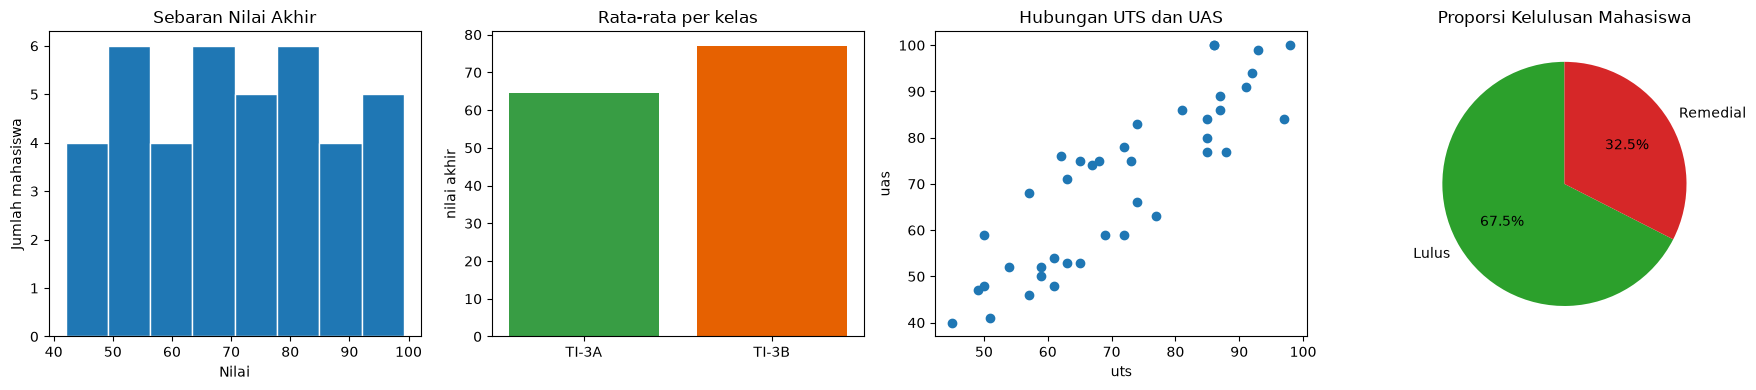

In [17]:
import matplotlib.pyplot as plt

# layout horizontal
fig = plt.figure(figsize=(18, 4))

# histogram
plt.subplot(1, 4, 1)
plt.hist(df["nilai_akhir"], bins=8, edgecolor="white")
plt.title("Sebaran Nilai Akhir")
plt.xlabel("Nilai")
plt.ylabel("Jumlah mahasiswa")

# bar chart
plt.subplot(1, 4, 2)
rata_kelas = df.groupby("kelas")["nilai_akhir"].mean()

plt.bar(rata_kelas.index, rata_kelas.values, color=["#389d44", "#e66101"])
plt.title("Rata-rata per kelas")
plt.ylabel("nilai akhir")

# scatter plot
plt.subplot(1, 4, 3)
plt.scatter(df["uts"], df["uas"])
plt.title("Hubungan UTS dan UAS")
plt.xlabel("uts"); plt.ylabel("uas")

# Pie Chart kelulusan 
plt.subplot(1, 4, 4)
status = df["nilai_akhir"].apply(lambda x: "Lulus" if x >= 60 else "Remedial")
status_counts = status.value_counts()

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ca02c", "#d62728"],
)
plt.title("Proporsi Kelulusan Mahasiswa")

plt.tight_layout()

penjelasan(fig) #instruksi_tambahan="" untuk menambahkan instruksi tambahan 

plt.show()


### Kegiatan 4 — Berburu Dataset Terbuka di Kaggle

In [11]:
import pandas as pd

url = "https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/fifa_players.csv"
df2 = pd.read_csv(url)
df2.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


### Latihan Mandiri

#### Latihan 1 — Dari df nilai_mahasiswa: hitung rata-rata, minimum, dan maksimum kolom kehadiran, lalu buat histogramnya (lengkap dengan judul dan label).

	Statistik Kehadiran Mahasiswa
Rata-rata : 84.03
Minimum   : 70
Maksimum  : 100


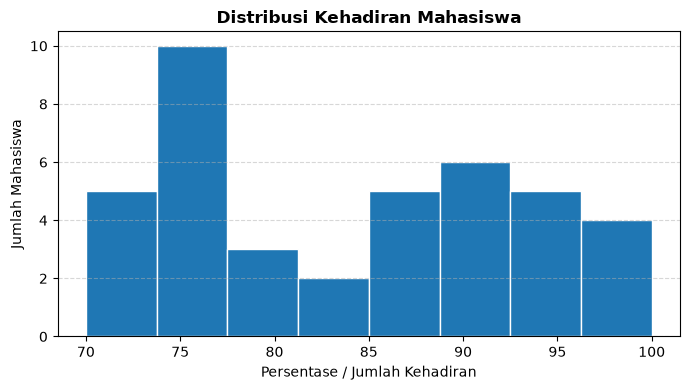

Berikut adalah penjelasan sederhana mengenai grafik tersebut:

---

### 📊 Apa yang Ditunjukkan oleh Grafik Ini?

Grafik ini memperlihatkan **seberapa rajin mahasiswa hadir di kelas**, mulai dari kehadiran 70% sampai 100%. 

* **Garis mendatar (bawah):** Menunjukkan persentase kehadiran (semakin ke kanan, semakin rajin hadir).
* **Garis tegak (samping):** Menunjukkan jumlah mahasiswanya (semakin tinggi baloknya, semakin banyak orangnya).

---

### 🔍 3 Hal Menarik yang Terlihat dari Grafik:

#### 1. Balok Tertinggi Ada di Angka ~75% (Juara Terbanyak)
Balok yang paling menjulang tinggi berada di kisaran **74% – 77%**, dengan jumlah **10 mahasiswa**. 
> *Mengapa ini terjadi?* Di banyak kampus, syarat minimal untuk boleh ikut ujian akhir biasanya adalah **75%**. Jadi, banyak mahasiswa yang "bermain aman" di batas garis ini.

#### 2. Terbelah Menjadi "Dua Kubu"
Jika diperhatikan, grafik ini seperti memiliki **dua bukit**:
* **Bukit Pertama (Kiri / 70% – 77%):** Mahasiswa yang kehadirannya pas-pasan di batas minimal.
* **Bukit Kedua (Kanan / 85% – 100%):** Mahasiswa yang sangat rajin dan jarang sekali absen (jumlahnya cukup banyak dan tersebar merata).

#### 3. Area Tengah Justru Sepi (80% – 85%)
Sangat sedikit mahasiswa yang berada di tengah-tengah (hanya 2 orang di kisaran 81–85%). Mahasiswa di kelas ini cenderung terbagi tegas: **kalau tidak rajin sekali, ya pas-pasan sekali**.

---

### 💡 Analogi Sederhana: *"Indikator Baterai HP"*

Bayangkan kebiasaan orang saat mengisi daya baterai HP:
1. **Tipe Pas-pasan (Kelompok 75%):** Mirip orang yang baru mencari colokan listrik saat baterai HP-nya sudah merah (15–20%). Mereka menghitung betul jatah absen agar tidak kena sanksi, yang penting "HP tidak mati" (masih bisa ikut ujian).
2. **Tipe Rajin (Kelompok 90–100%):** Mirip orang yang gelisah kalau baterai turun sedikit, jadi selalu membawa *powerbank* dan menjaga baterai tetap penuh di atas 90%. Mereka hadir hampir di setiap pertemuan.

---

### 📝 Kesimpulan Singkat
Semua mahasiswa di kelas ini sebenarnya masih tergolong aman (tidak ada yang kehadirannya di bawah 70%). Namun, dinamika kelas ini unik karena terbagi menjadi dua kelompok besar: **tim pemburu batas minimal absen** dan **tim yang hampir selalu masuk kuliah**.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/nilai_mahasiswa.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

rata_kehadiran = df["kehadiran"].mean()
min_kehadiran = df["kehadiran"].min()
max_kehadiran = df["kehadiran"].max()

print("\tStatistik Kehadiran Mahasiswa")
print(f"Rata-rata : {rata_kehadiran:.2f}")
print(f"Minimum   : {min_kehadiran}")
print(f"Maksimum  : {max_kehadiran}")

# histogram


fig = plt.figure(figsize=(7, 4))
plt.hist(df["kehadiran"], bins=8, edgecolor="white")

plt.title("Distribusi Kehadiran Mahasiswa", fontweight="bold")
plt.xlabel("Persentase / Jumlah Kehadiran")
plt.ylabel("Jumlah Mahasiswa")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
penjelasan(fig) # instruksi_tambahan="" (untuk menambahkan instruksi tambahan jika diperlukan)

#### Latihan 2 — Tambahkan kolom status berisi LULUS/REMIDI (batas 60 pada nilai_akhir), lalu tampilkan berapa mahasiswa REMIDI per kelas (petunjuk: groupby + filter).

In [13]:
import pandas as pd

if "nilai_akhir" not in df.columns:
    df["nilai_akhir"] = 0.4 * df["uts"] + 0.6 * df["uas"]

df["status"] = df["nilai_akhir"].apply(
    lambda x: "LULUS" if x >= 60 else "REMIDI"
)

remidi_per_kelas = (
    df[df["status"] == "REMIDI"]
    .groupby("kelas")["nama"]
    .count()
    .reset_index(name="jumlah_remidi")
)

print("Jumlah Mahasiswa REMIDI per Kelas")
print(remidi_per_kelas.to_string(index=False))

Jumlah Mahasiswa REMIDI per Kelas
kelas  jumlah_remidi
TI-3A              8
TI-3B              5


#### Latihan 3 — EDA mini dataset terbuka: dengan dataset Kaggle dari Kegiatan 4, tuliskan dalam sel markdown: sumber + lisensi, arti 3 kolom, lalu tunjukkan 3 temuan (statistik/grafik) dengan kode.

#### 1. Sumber & Lisensi
* **Sumber Dataset:** Football Players Data
* **Lisensi:** Apache 2.0
* **Authors:** Masood Ahmed

#### 2. 3 Kolom Temuan
* `overall_rating`: Nilai performa keseluruhan pemain (skala 1–99).
* `age`: Usia pemain dalam satuan tahun.
* `value_euro`: Nilai pasar pemain dalam mata uang Euro.

	Rata rata Rating
Rata-rata rating pemain: 66.2

Top 5 Pemain Termahal
        name  age  overall_rating  value_euro
    L. Messi   31              94 110500000.0
   Neymar Jr   27              92 108000000.0
K. De Bruyne   27              91 102000000.0
     H. Kane   25              90  96500000.0
   E. Hazard   28              91  93000000.0


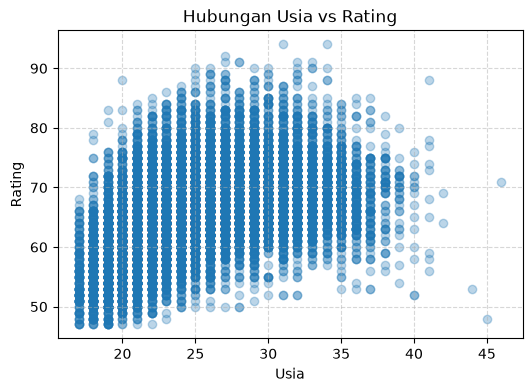

Percobaan dengan gemini-3.8-flash gagal: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Percobaan dengan gemini-3.5-flash gagal: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Tentu, mari kita bedah grafik **"Hubungan Usia vs Rating"** ini dengan cara yang santai dan mudah dibayangkan seperti sedang mengobrol santai! ☕

---

### 🎮 **Bayangkan Ini Seperti Game Sepak Bola (Contoh: FIFA / PES)**
Pernah main game bola di mana setiap pemain punya kartu dengan angka kemampuan (rating)? Nah, grafik ini mirip banget seperti saat kita mengumpulkan data seluruh pemain bola di dunia dan mencocokkan **umur** mereka dengan **nilai kemampuannya**.

*   **Sumbu Mendatar (Usia):** Umur para pemain (dari belasan tahun sampai 45 tahun).
*   **Sumbu Tegak (Rating):** Seberapa jago mereka (nilai dari sekitar 50 sampai 90+).
*   **Titik-Titik Biru:** Setiap titik melambangkan satu orang pemain. Karena pemainnya banyak banget, titik-titiknya menumpuk sampai kelihatan seperti garis-garis tebal.

---

### 📈 **Apa Cerita di Balik Grafik Ini?**

1. **Masa Muda (Usia 17 - 21 Tahun):**
   * Perhatikan di sebelah kiri, titik-titiknya masih pendek (mentok di angka 70-80-an). 
   * **Analogi:** Seperti atlet pemula. Mereka masih muda dan bersemangat, tapi jam terbangnya belum banyak, jadi nilainya belum terlalu tinggi.

2. **Masa Puncak / *Prime Time* (Usia 25 - 33 Tahun):**
   * Lihat bagian tengah yang paling "gemuk" dan tinggi (bisa mencapai nilai hampir 95!). 
   * **Analogi:** Ini adalah usia "emas" seorang atlet. Tenaga masih kuat, pengalaman sudah matang. Di rentang umur inilah kita bisa menemukan pemain-pemain paling hebat dengan nilai tertinggi.

3. **Masa Senior (Usia 35 Tahun ke Atas):**
   * Semakin ke kanan (semakin tua), jumlah titiknya semakin sedikit dan mulai menyebar ke bawah.
   * **Analogi:** Saat fisik mulai melambat karena umur, performanya biasanya sedikit menurun, sehingga pemain di usia senja jarang sekali yang punya nilai super tinggi (meskipun tetap ada beberapa pengecualian yang masih hebat!).

---

### 🎯 **Kesimpulan Singkat:**
Grafik ini menunjukkan bahwa **usia paling produktif dan jago** ada di kisaran **25 sampai 33 tahun**. Sebelum dan sesudah usia itu, kemampuan rata-rata cenderung tidak setinggi di masa emas tersebut.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/fifa_players.csv"
df2 = pd.read_csv(url)

# Rata rata dan sebaran rating
print("\tRata rata Rating")
print(f"Rata-rata rating pemain: {df2['overall_rating'].mean():.1f}")

# 5 Pemain termahal
print("\nTop 5 Pemain Termahal")
top_mahal = df2.sort_values(by="value_euro", ascending=False)[
    ["name", "age", "overall_rating", "value_euro"]
].head(5)
print(top_mahal.to_string(index=False))

# Grafik hubungan Usia vs Rating
fig = plt.figure(figsize=(6, 4))
plt.scatter(df2["age"], df2["overall_rating"], alpha=0.3)
plt.title("Hubungan Usia vs Rating")
plt.xlabel("Usia")
plt.ylabel("Rating")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
penjelasan(fig) # instruksi_tambahan="" (untuk menambahkan instruksi tambahan jika diperlukan)

## Buku Ajar - Bab 03 Representasi Pengetahuan

### **A. Pilihan Ganda**

#### 1. p → q bernilai SALAH hanya ketika…
* [ ] (a) p benar, q benar
* [x] **(b) p benar, q salah**
* [ ] (c) p salah, q benar
* [ ] (d) p salah, q salah

#### 2. “Jika servernya mati, situs tidak bisa diakses. Situs BISA diakses.” Kesimpulan sah:
* [ ] (a) server mati
* [x] **(b) server tidak mati**
* [ ] (c) situs lambat
* [ ] (d) tidak ada kesimpulan

#### 3. Menyimpan profil produk (nama, harga, stok, kategori) paling alami memakai…
* [ ] (a) tabel kebenaran
* [x] **(b) frame/dictionary**
* [ ] (c) kuantor
* [ ] (d) tumpukan

#### 4. Pewarisan pada jaringan semantik berarti…
* [ ] (a) semua simpul bernilai sama
* [x] **(b) konsep khusus otomatis mendapat sifat konsep umumnya**
* [ ] (c) panah boleh dua arah
* [ ] (d) fakta lama dihapus

#### 5. Kumpulan fakta kasus yang sedang ditangani sistem berbasis aturan disebut…
* [ ] (a) basis aturan
* [x] **(b) memori kerja**
* [ ] (c) mesin inferensi
* [ ] (d) antarmuka

### **B. Esai**

#### 1. Buktikan dengan tabel kebenaran bahwa ¬(p ∧ q) ekuivalen dengan ¬p ∨ ¬q (hukum De Morgan) — tunjukkan kolom keduanya identik pada keempat baris.
| p | q | p ∧ q | ¬(p ∧ q) | ¬p | ¬q | ¬p ∨ ¬q |
|---|---|-------|----------|----|----|---------|
| B | B | B     | S        | S  | S  | S       |
| B | S | S     | B        | S  | B  | B       |
| S | B | S     | B        | B  | S  | B       |
| S | S | S     | B        | B  | B  | B       |

##### Kolom ¬(p ∧ q) dan ¬p ∨ ¬q memiliki nilai yang persis sama pada semua baris (S, B, B, B), sehingga terbukti ekuivalen.
---

#### 2. Terjemahkan ke logika predikat: (a) “Semua praktikum dikumpulkan lewat LMS”; (b) “Ada mahasiswa yang belum mengumpulkan P05”; (c) “Setiap mahasiswa yang mengumpulkan tepat waktu mendapat nilai penuh”.
* (a) ∀x praktikum(x) → kumpulLMS(x)
* (b) ∃x mahasiswa(x) ∧ ¬kumpulP05(x)
* (c) ∀x (mahasiswa(x) ∧ kumpulTepatWaktu(x)) → nilaiPenuh(x)

---

#### 3. Susun lima aturan produksi untuk satu domain yang kamu kuasai (mis. perawatan motor, jaringan WiFi kos), dengan minimal satu rantai (kesimpulan sebuah aturan menjadi kondisi aturan lain).
* R1: JIKA starter_mati DAN klakson_lemah MAKA aki_soak
* R2: JIKA aki_soak MAKA ganti_aki
* R3: JIKA mesin_kasar DAN km_lebih_2000 MAKA ganti_oli
* R4: JIKA motor_brebet DAN busi_hitam MAKA ganti_busi
* R5: JIKA tarikan_berat DAN vbelt_retak MAKA ganti_vbelt

#### Kesimpulan : Hasil dari R1 (aki_soak) menjadi pemicu untuk aturan R2

---

#### Gambarkan jaringan semantik minimal 6 simpul untuk dunia perkuliahanmu (mahasiswa, MK, dosen, prodi, gedung, …) dengan panah berlabel; tunjukkan satu sifat yang diperoleh lewat pewarisan
* Konsep & relasi:
  * Mahasiswa --(mengambil)--> MK Sistem Cerdas
  * Dosen --(mengajar)--> MK Sistem Cerdas
  * MK Sistem Cerdas --(is-a)--> MK Wajib[cite: 1]
  * MK Sistem Cerdas --(diadakan_di)--> Ruang Lab
  * Ruang Lab --(bagian_dari)--> Gedung Kuliah
  * Mahasiswa --(is-a)--> Mahasiswa D3
* Pewarisan sifat: Karena Ruang Lab berada di Gedung Kuliah, maka perkuliahan MK Sistem Cerdas otomatis mewarisi lokasi di Gedung Kuliah.
---

#### 5. Kasus penguin: penguin is-a burung tetapi tidak bisa terbang. Usulkan cara representasi frame menangani pengecualian ini, dan jelaskan pelajaran umumnya tentang pengetahuan dunia nyata.
* Solusi frame: Frame Burung diberi slot nilai bawaan `terbang: bisa`, sedangkan frame Penguin diberi slot `terbang: tidak bisa` untuk menimpa nilai bawaan tersebut.
* Pelajaran: Fakta dunia nyata tidak selalu mutlak benar/salah dan penuh dengan pengecualian. Sistem representasi harus fleksibel agar bisa membatalkan asumsi umum saat bertemu fakta khusus.